# 04 - Agregacion a sub_grade y curvas de elasticidad (Fases 4 y 6)

**El puente entre los dos niveles de granularidad del proyecto** (ver README): los modelos de demanda, PD y LGD se entrenaron a nivel de cliente individual (notebooks 02 y 03). Aquí se agregan sus predicciones a nivel de **sub_grade** (A1...G5, 35 niveles) -- el nivel que usa el optimizador de las Fases 8-9 -- promediando las predicciones individuales de los clientes reales de cada sub_grade. **No se reentrena ningún modelo agregado.**

Solo `accepted` tiene `sub_grade` asignado (es la etiqueta que LendingClub pone a los préstamos que sí otorga, tras underwriting), así que toda la agregación de esta notebook usa `accepted`, no el dataset de demanda combinado.

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.aggregation import (  # noqa: E402
    RATE_GRID,
    add_risk_percentile_accepted,
    aggregate_pd_lgd,
    compute_elasticity_curve,
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (9, 4)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

accepted_with_risk = pd.read_csv(PROCESSED_DIR / "accepted_with_risk.csv.gz", low_memory=False)
accepted_with_risk = add_risk_percentile_accepted(accepted_with_risk)
demand_pipeline = joblib.load(MODELS_DIR / "demand_model.joblib")

print(f"accepted_with_risk: {accepted_with_risk.shape}")
print(f"sub_grades: {accepted_with_risk['sub_grade'].nunique()}")

accepted_with_risk: (149996, 158)
sub_grades: 35


## Fase 4 -- Agregación de PD y LGD a sub_grade

`PD_i` y `LGD_i` se calculan como el promedio de las predicciones individuales (`pd_individual`, `lgd_individual` de `03_risk_estimation.ipynb`) de todos los clientes reales de cada sub_grade. Para `LGD_i`, si un sub_grade tiene menos de `MIN_CHARGEOFF_SAMPLE=30` préstamos Charged Off, el promedio modelado se reemplaza por el benchmark de industria (`LGD_INDUSTRY_BENCHMARK=45%`) -- ver justificación en `src/risk_model.py`.

In [2]:
pd_lgd_by_subgrade = aggregate_pd_lgd(accepted_with_risk)
pd_lgd_by_subgrade

,sub_grade,PD,LGD,n_chargeoff,n_clients,LGD_source
0,A1,0.078700,0.903536,101,5755,modelado
1,A2,0.088061,0.906946,113,4721,modelado
2,A3,0.099767,0.907448,130,4817,modelado
3,A4,0.115982,0.908278,241,6140,modelado
4,A5,0.126042,0.907533,359,7046,modelado
5,B1,0.145947,0.908632,476,8251,modelado
6,B2,0.159011,0.908358,554,8517,modelado
7,B3,0.169307,0.907313,719,8626,modelado
8,B4,0.182454,0.908307,819,9108,modelado
9,B5,0.190975,0.908191,911,9406,modelado


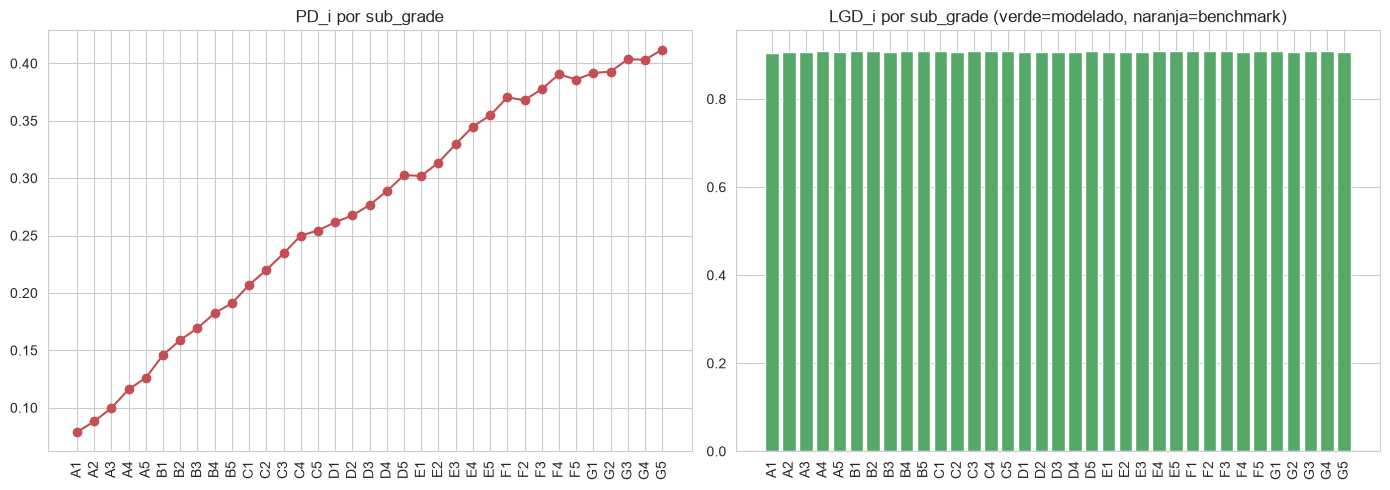

Sub_grades que usan benchmark de industria (muestra chica): []


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pd_lgd_by_subgrade["sub_grade"], pd_lgd_by_subgrade["PD"], marker="o", color="#C44E52")
axes[0].set_title("PD_i por sub_grade")
axes[0].tick_params(axis="x", rotation=90)

colors = ["#55A868" if s == "modelado" else "#DD8452" for s in pd_lgd_by_subgrade["LGD_source"]]
axes[1].bar(pd_lgd_by_subgrade["sub_grade"], pd_lgd_by_subgrade["LGD"], color=colors)
axes[1].set_title("LGD_i por sub_grade (verde=modelado, naranja=benchmark)")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

print(f"Sub_grades que usan benchmark de industria (muestra chica): "
      f"{pd_lgd_by_subgrade.loc[pd_lgd_by_subgrade['LGD_source']=='benchmark_industria', 'sub_grade'].tolist()}")

**Lectura de negocio:** `PD_i` sube monótonamente de A1 a G5 (~8% a ~41%), exactamente como debía ser -- confirma que la política de segmentación de LendingClub está bien alineada con el riesgo de default real observado. `LGD_i` es notablemente estable alrededor de ~91% en casi todos los sub_grades (el riesgo de default varía mucho entre grados, pero *dado que* un préstamo cae en default, la fracción de pérdida no varía tanto por grado -- consistente con ser crédito no garantizado, donde la recuperación depende más de la gestión de cobranza que del perfil de riesgo original del cliente). Todos los sub_grades de esta muestra tuvieron suficiente volumen de Charged Off para usar el LGD modelado -- el fallback a benchmark de industria no se activó, pero queda disponible como salvaguarda para muestras más chicas.

## Fase 6 -- Curvas de elasticidad por sub_grade

Para cada uno de los 35 sub_grades, se evalúa el modelo de demanda sobre todos sus clientes reales a cada una de las 15 tasas candidatas de `RATE_GRID`, y se promedia -- esto construye `p_{i,k}` = F̄_i(r), la curva de "probabilidad de aceptación vs. tasa" que define Phillips, al nivel de granularidad que usará el optimizador.

In [4]:
elasticity = compute_elasticity_curve(accepted_with_risk, demand_pipeline, rate_grid=RATE_GRID)
print(f"elasticity: {elasticity.shape} (35 sub_grades x {len(RATE_GRID)} tasas)")
elasticity.head(10)

elasticity: (525, 3) (35 sub_grades x 15 tasas)


,sub_grade,tasa,p_aceptacion
0,A1,5.00,0.807942
35,A1,6.79,0.793285
70,A1,8.57,0.778294
105,A1,10.36,0.762851
140,A1,12.14,0.747182
175,A1,13.93,0.731161
210,A1,15.71,0.715015
245,A1,17.50,0.698606
280,A1,19.29,0.682063
315,A1,21.07,0.665511


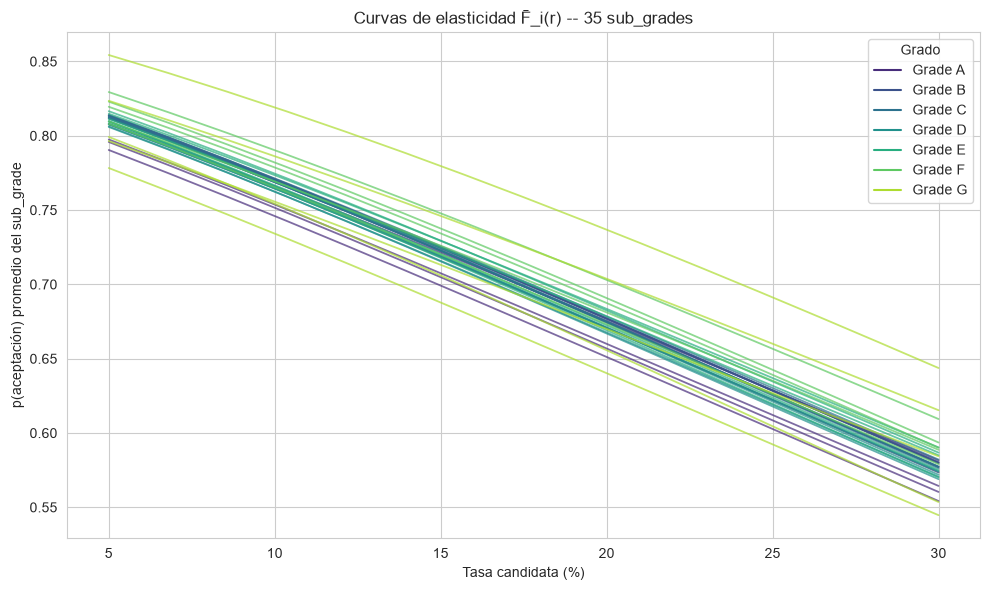

In [5]:
grade_letters = sorted(elasticity["sub_grade"].str[0].unique())
palette = dict(zip(grade_letters, sns.color_palette("viridis", len(grade_letters))))

fig, ax = plt.subplots(figsize=(10, 6))
for sub_grade, group in elasticity.groupby("sub_grade"):
    letter = sub_grade[0]
    ax.plot(
        group["tasa"],
        group["p_aceptacion"],
        color=palette[letter],
        alpha=0.7,
        linewidth=1.3,
    )

handles = [plt.Line2D([0], [0], color=palette[g], label=f"Grade {g}") for g in grade_letters]
ax.legend(handles=handles, title="Grado", loc="upper right")
ax.set_xlabel("Tasa candidata (%)")
ax.set_ylabel("p(aceptación) promedio del sub_grade")
ax.set_title("Curvas de elasticidad F̄_i(r) -- 35 sub_grades")
plt.tight_layout()
plt.show()

In [6]:
def _slope(group: pd.DataFrame) -> float:
    return np.polyfit(group["tasa"], group["p_aceptacion"], deg=1)[0]


elasticity_summary = (
    elasticity.groupby("sub_grade")
    .apply(_slope, include_groups=False)
    .rename("pendiente_p_vs_tasa")
    .reset_index()
    .sort_values("pendiente_p_vs_tasa")
)

print("Sub_grades MÁS elásticos (caída más pronunciada de p al subir la tasa):")
print(elasticity_summary.head(5).to_string(index=False))
print("\nSub_grades MÁS inelásticos (p cambia poco con la tasa):")
print(elasticity_summary.tail(5).to_string(index=False))

Sub_grades MÁS elásticos (caída más pronunciada de p al subir la tasa):
sub_grade  pendiente_p_vs_tasa
       G1            -0.009905
       E3            -0.009594
       D2            -0.009576
       D1            -0.009564
       C1            -0.009526

Sub_grades MÁS inelásticos (p cambia poco con la tasa):
sub_grade  pendiente_p_vs_tasa
       F4            -0.008886
       F5            -0.008854
       G3            -0.008534
       G4            -0.008473
       G2            -0.008370


**Lectura de negocio:** revisar la tabla de arriba para identificar el patrón real en los datos. En general se espera que los segmentos de **menor riesgo** (grados A/B) sean más elásticos -- esos clientes suelen tener más alternativas de crédito (tarjetas, otros bancos) y son más sensibles al precio, mientras que los segmentos de **mayor riesgo** (F/G) tienden a ser más inelásticos porque tienen menos alternativas de financiamiento disponibles. Esta asimetría es precisamente el mecanismo de **selección adversa por precio** que Phillips (2013) menciona como problema abierto (Concepto clave 5 del proyecto): si los clientes de bajo riesgo son los más sensibles al precio, subir tasas de forma pareja empeora el mix de riesgo del portafolio -- los mejores clientes se van primero.

## Guardar tablas agregadas para la Fase 8-9

Se guarda `pd_lgd_by_subgrade` y `elasticity` (p_{i,k} por sub_grade y tasa candidata) en `data/processed/` -- son el insumo directo de la función objetivo del optimizador. También se agrega el monto y plazo promedio por sub_grade (`P_i`, `n_i` en la notación de Phillips), necesarios para la fórmula de PVNII.

In [7]:
monto_plazo = (
    accepted_with_risk.groupby("sub_grade")
    .agg(P_i=("funded_amnt", "mean"), n_i=("term", "mean"), D_i=("funded_amnt", "size"))
    .reset_index()
)

subgrade_params = pd_lgd_by_subgrade.merge(monto_plazo, on="sub_grade")

subgrade_params.to_csv(PROCESSED_DIR / "subgrade_params.csv", index=False)
elasticity.to_csv(PROCESSED_DIR / "subgrade_elasticity.csv", index=False)

print("Guardado:")
print(" -", PROCESSED_DIR / "subgrade_params.csv")
print(" -", PROCESSED_DIR / "subgrade_elasticity.csv")
subgrade_params.head()

Guardado:
 - C:\Users\josue\credit-pricing-optimizer\data\processed\subgrade_params.csv
 - C:\Users\josue\credit-pricing-optimizer\data\processed\subgrade_elasticity.csv


,sub_grade,PD,LGD,n_chargeoff,n_clients,LGD_source,P_i,n_i,D_i
0,A1,0.078700,0.903536,101,5755,modelado,15169.782798,36.629713,5755
1,A2,0.088061,0.906946,113,4721,modelado,14226.265622,36.569371,4721
2,A3,0.099767,0.907448,130,4817,modelado,14281.990866,36.448412,4817
3,A4,0.115982,0.908278,241,6140,modelado,14823.978013,38.294463,6140
4,A5,0.126042,0.907533,359,7046,modelado,14323.786546,38.139086,7046


## Resumen y próximos pasos

- `PD_i` y `LGD_i` agregados por sub_grade (35 filas), con fallback a benchmark de industria para muestras chicas.
- `p_{i,k}` (curvas de elasticidad) calculado para las 15 tasas candidatas de `RATE_GRID` en los 35 sub_grades.
- `P_i` (monto promedio) y `n_i` (plazo promedio) agregados, completando los parámetros que necesita la fórmula de PVNII de Phillips.
- Todo guardado en `data/processed/subgrade_params.csv` y `data/processed/subgrade_elasticity.csv`.
- Próximo notebook: `05_optimization.ipynb` -- función objetivo (Revenue vs. Profitability) y optimización con PuLP (Fase 8).